In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import duckdb

In [ ]:
data=pd.read_csv('/content/funnel_analysis_data.csv')

In [ ]:
data.head(5)

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
0,USR00001,SES00001,Browse,2025-10-28 07:33:50,Desktop,West,Organic,Home,0.0,Yes
1,USR00001,SES00001,Add to Cart,2025-10-28 07:36:50,Tablet,East,Social Media,Beauty,0.0,Yes
2,USR00001,SES00001,Checkout,2025-10-28 07:40:50,Mobile,West,Email,Beauty,0.0,Yes
3,USR00002,SES00002,Browse,2025-10-19 09:15:10,Desktop,East,Email,Electronics,0.0,No
4,USR00002,SES00002,Add to Cart,2025-10-19 09:18:10,Mobile,West,Social Media,Fashion,0.0,No


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21663 entries, 0 to 21662
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           21663 non-null  object 
 1   Session_ID        21663 non-null  object 
 2   Event             21663 non-null  object 
 3   Timestamp         21663 non-null  object 
 4   Device            21663 non-null  object 
 5   Region            21663 non-null  object 
 6   Channel           21663 non-null  object 
 7   Product_Category  21663 non-null  object 
 8   Revenue           21663 non-null  float64
 9   Bounce_Flag       21663 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.7+ MB


In [ ]:
row , col = data.shape
print(f"Rows: {row} and Columns: {col} in Dataset")

Rows: 21663 and Columns: 10 in Dataset


In [ ]:
data.describe()

,Revenue
count,21663.000000
mean,54.304841
std,262.692471
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1998.510000


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.isnull().sum()

,0
User_ID,0
Session_ID,0
Event,0
Timestamp,0
Device,0
Region,0
Channel,0
Product_Category,0
Revenue,0
Bounce_Flag,0


In [ ]:
data.tail(7)

,User_ID,Session_ID,Event,Timestamp,Device,Region,Channel,Product_Category,Revenue,Bounce_Flag
21656,USR09998,SES09998,Add to Cart,2025-10-09 12:06:15,Desktop,South,Email,Home,0.00,Yes
21657,USR09998,SES09998,Checkout,2025-10-09 12:08:15,Tablet,East,Email,Fashion,0.00,Yes
21658,USR09999,SES09999,Browse,2025-10-03 17:22:58,Desktop,South,Google Ads,Electronics,0.00,No
21659,USR09999,SES09999,Add to Cart,2025-10-03 17:26:58,Tablet,West,Social Media,Fashion,0.00,No
21660,USR09999,SES09999,Checkout,2025-10-03 17:29:58,Mobile,North,Email,Fashion,0.00,No
21661,USR09999,SES09999,Purchase,2025-10-03 17:34:58,Mobile,East,Email,Fashion,960.65,No
21662,USR10000,SES10000,Browse,2025-10-15 20:32:43,Mobile,South,Google Ads,Beauty,0.00,Yes


In [ ]:
data['Timestamp']=pd.to_datetime(data['Timestamp'])


In [ ]:
data=data.sort_values(by=['User_ID','Timestamp'])
data['Hour_of_Day'] = data['Timestamp'].dt.hour
data['Day_of_Week'] = data['Timestamp'].dt.day_name()

In [ ]:
data['Time_Since_Last_Action'] = data.groupby('Session_ID')['Timestamp'].diff().dt.total_seconds()

In [ ]:
data['Time_Since_Last_Action']=data['Time_Since_Last_Action'].fillna(0)

In [ ]:
sql_query = """
    SELECT
        Event AS Funnel_Stage,
        COUNT(DISTINCT Session_ID) AS Users_At_Stage
    FROM data
    GROUP BY Event
    ORDER BY
        CASE Event
            WHEN 'Browse' THEN 1
            WHEN 'Add to Cart' THEN 2
            WHEN 'Checkout' THEN 3
            WHEN 'Purchase' THEN 4
        END;
"""

# Run the query using DuckDB and save it as a new dataframe
funnel_summary = duckdb.query(sql_query).df()

print("SQL Aggregation Complete!")
display(funnel_summary)

SQL Aggregation Complete!


,Funnel_Stage,Users_At_Stage
0,Browse,10000
1,Add to Cart,7059
2,Checkout,3524
3,Purchase,1080


In [ ]:
sql_query = """
SELECT
    Device,
    COUNT(DISTINCT CASE WHEN Event = 'Browse' THEN Session_ID END) AS Browse_Users,
    COUNT(DISTINCT CASE WHEN Event = 'Add to Cart' THEN Session_ID END) AS Cart_Users,
    COUNT(DISTINCT CASE WHEN Event = 'Checkout' THEN Session_ID END) AS Checkout_Users,
    COUNT(DISTINCT CASE WHEN Event = 'Purchase' THEN Session_ID END) AS Purchase_Users
FROM data
GROUP BY Device;
"""

device_funnel_summary = duckdb.query(sql_query).df()

print("Device Funnel Aggregation Complete!")
display(device_funnel_summary)

Device Funnel Aggregation Complete!


,Device,Browse_Users,Cart_Users,Checkout_Users,Purchase_Users
0,Desktop,3331,2399,1177,328
1,Tablet,3324,2331,1199,383
2,Mobile,3345,2329,1148,369


In [ ]:
sql_query = """
  WITH Funnel_Counts AS (
    SELECT
        Event AS Funnel_Stage,
        COUNT(DISTINCT Session_ID) AS Users_At_Stage,
        CASE Event
            WHEN 'Browse' THEN 1
            WHEN 'Add to Cart' THEN 2
            WHEN 'Checkout' THEN 3
            WHEN 'Purchase' THEN 4
        END AS Stage_Order
    FROM data
    GROUP BY Event
)
SELECT
    Funnel_Stage,
    Users_At_Stage,
    LAG(Users_At_Stage) OVER (ORDER BY Stage_Order) AS Previous_Stage_Users,
    ROUND((Users_At_Stage * 100.0) / LAG(Users_At_Stage) OVER (ORDER BY Stage_Order), 2) AS Step_Conversion_Rate_Pct
FROM Funnel_Counts
ORDER BY Stage_Order;
"""

step_conversion_rate = duckdb.query(sql_query).df()

print("Step Conversion Rate Aggregation Complete!")
display(step_conversion_rate)

Step Conversion Rate Aggregation Complete!


,Funnel_Stage,Users_At_Stage,Previous_Stage_Users,Step_Conversion_Rate_Pct
0,Browse,10000,<NA>,NaN
1,Add to Cart,7059,10000,70.59
2,Checkout,3524,7059,49.92
3,Purchase,1080,3524,30.65


In [ ]:
sql_query = """
    SELECT
        Product_Category,
        COUNT(DISTINCT Session_ID) AS Total_Purchases,
        ROUND(SUM(Revenue), 2) AS Total_Revenue,
        ROUND(SUM(Revenue) / COUNT(DISTINCT Session_ID), 2) AS Average_Order_Value
    FROM data
    WHERE Event = 'Purchase'
    GROUP BY Product_Category
    ORDER BY Total_Revenue DESC;
"""

category_revenue = duckdb.query(sql_query).df()
display(category_revenue)

,Product_Category,Total_Purchases,Total_Revenue,Average_Order_Value
0,Electronics,229,256035.81,1118.06
1,Fashion,223,244761.32,1097.58
2,Home,212,230160.90,1085.66
3,Sports,215,227888.10,1059.94
4,Beauty,201,217559.65,1082.39


In [ ]:
import plotly.graph_objects as go

fig = go.Figure(go.Funnel(
    y = step_conversion_rate['Funnel_Stage'],
    x = step_conversion_rate['Users_At_Stage'],
    textinfo = "value+percent initial",
    marker = {"color": ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]}
))

fig.update_layout(title_text="E-Commerce Funnel Drop-Off", title_x=0.5)
fig.show()

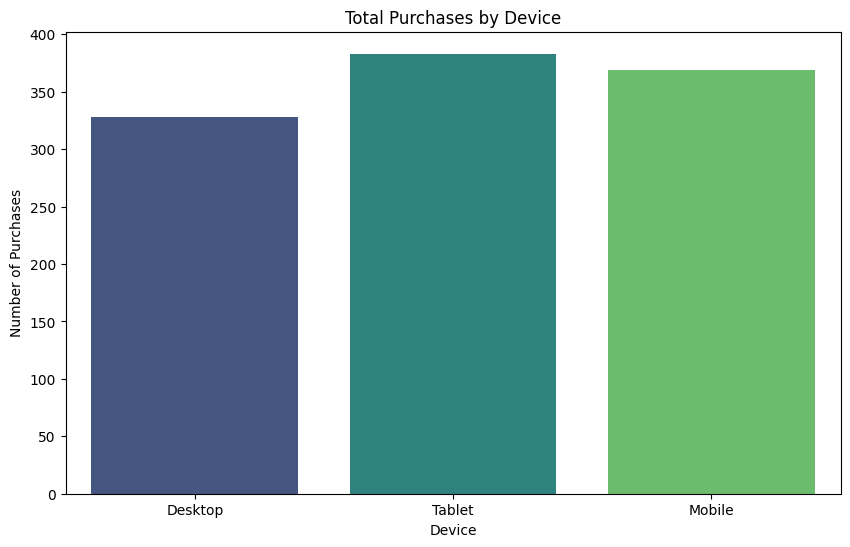

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=device_funnel_summary, x='Device', y='Purchase_Users', palette='viridis')
plt.title('Total Purchases by Device')
plt.ylabel('Number of Purchases')
plt.show()

In [ ]:
data.to_csv('cleaned_funnel_data.csv', index=False)

print("Data exported successfully! Check the folder icon on the left to download it.")

Data exported successfully! Check the folder icon on the left to download it.
